In [2]:
import numpy as np
import h5py
import time
import datetime

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.make_orbits import *
from helpers.config import *
from pytdi.michelson import *
from pytdi import LISATDICombination
from scipy.signal import welch

from lisaorbits import KeplerianOrbits, EqualArmlengthOrbits, OEMOrbits
from lisaglitch import LPFLibraryGlitch
from scipy.signal import coherence

import warnings
warnings.filterwarnings("ignore")

OEM preferred interpolation method ignored, using spline interpolation (see InterpolatedOrbits for details)


In [3]:
def estimate_psd(data, sample_freq, nperseg, noverlap=None):
    
    f_psd, psd = welch(
        data,
        fs=sample_freq,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        scaling="density",
        return_onesided=True
    )
    return f_psd, psd

In [4]:
disable_dopplers = False
disable_noise = False
#disable_noise = ['test-mass', 'oms']
#disable_noise = ['laser']
disable_noise = ['laser', 'test-mass', 'oms']
orbits3_path = str(DIST / 'orbits' / 'orbits2.h5')
with h5py.File(orbits3_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(10 * 3600 / 0.25), 't_inj': 5 * 3600}

lisa_instrument = Instrument(size=pipe['size'], dt=pipe['dt'], t0=pipe['t0'],
        orbits=orbits3_path, physics_upsampling=1, aafilter=None,
        glitches=None, gws=None)

if disable_dopplers:
    lisa_instrument.disable_dopplers()
if disable_noise is True:
    lisa_instrument.disable_all_noises()
elif disable_noise is not False:
    lisa_instrument.disable_all_noises(disable_noise)

if os.path.exists(simulation_path):
    os.remove(simulation_path)

lisa_instrument.write(simulation_path)
data = Data.from_instrument(simulation_path)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [25]:
#data.delay_derivatives = None
X_data = X1.build(**data.args)(data.measurements)
Y_data = Y1.build(**data.args)(data.measurements)
Z_data = Z1.build(**data.args)(data.measurements)

In [6]:
mytdi_Y = LISATDICombination({
    'sci_12': [
        (1, []),
        (1, ['D_12', 'D_21']),
        (-1, ['D_32', 'D_23'])
    ],
    'sci_21': [
        (1, ['D_12']),
        (-1, ['D_32', 'D_23', 'D_12'])
    ],
    'sci_32': [
        (1, ['D_12', 'D_21']),
        (-1, [])
    ],
    'sci_23': [
        (1, ['D_12', 'D_21', 'D_32']),
        (-1, ['D_32'])
    ],
})

Y_data = mytdi_Y.build(**data.args)(data.measurements)

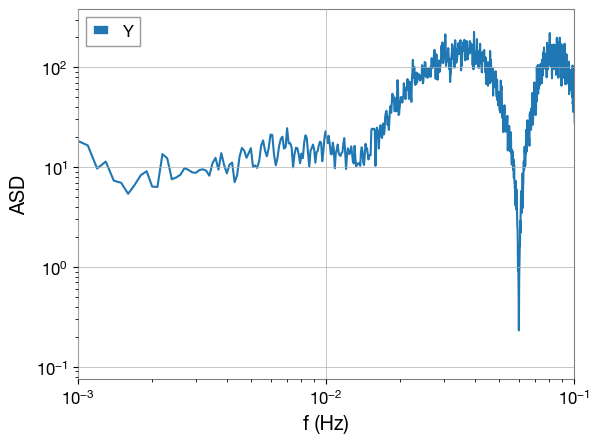

In [47]:
#channel = data.measurements['sci_12']
f_psd1, psd1 = estimate_psd(X_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd2, psd2 = estimate_psd(Y_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd3, psd3 = estimate_psd(Z_data, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)

#plt.loglog(f_psd1, np.sqrt(psd1), label='X')
plt.loglog(f_psd2, np.sqrt(psd2), label='Y')
#plt.loglog(f_psd3, np.sqrt(psd3), label='Z')
plt.xlim(1e-3, 1e-1)
#plt.ylim(1e-7, 1e-3)
plt.xlabel('f (Hz)')
plt.ylabel('ASD')
plt.legend()
plt.show()

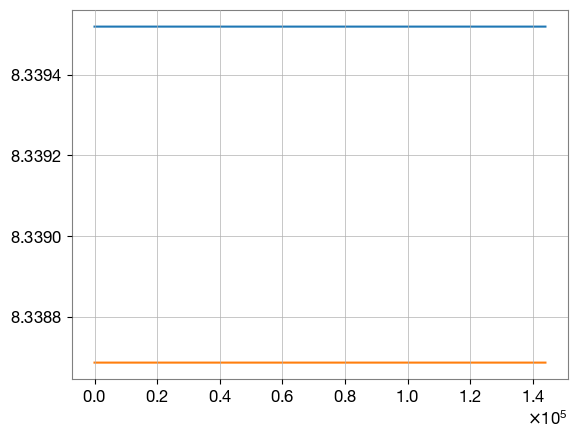

In [19]:
plt.plot(data.args['delays']['d_12'])
plt.plot(data.args['delays']['d_21'])

In [96]:
mytdi = LISATDICombination({
    'sci_12': [(1, ['D_12'])]
})

shifted = mytdi.build(**data.args)(data.measurements)

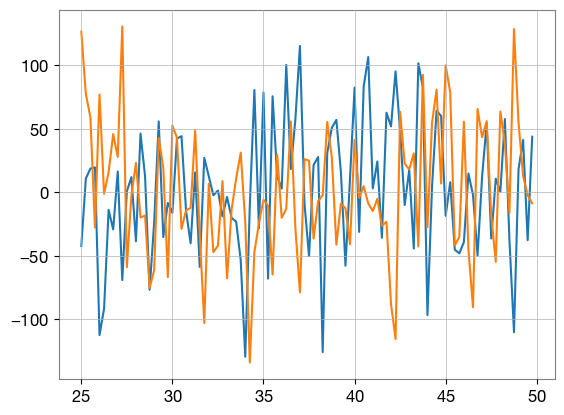

In [99]:
t = np.arange(0, 10*3600, 0.25)
plt.plot(t[100:200], data.measurements['sci_12'][100:200])
plt.plot(t[100:200], shifted[100:200])

In [ ]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

In [15]:
with h5py.File(orbits_path, "r") as f:
    for key, value in f.attrs.items():
        print(key, value)

check_input True
dt 0.25
ext raise
filename_1 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem1
filename_2 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem2
filename_3 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem3
generator OEMOrbits
git_url https://gitlab.in2p3.fr/lisa-simulation/orbits
ignore_shapiro False
interp_order 5
size 345600
t0 2073297530.8174996
t_end 2412464618.8153605
t_init 2073211130.8174996
t_start 2073211130.8174996
tt_method analytic
tt_niter 4
tt_order 2
version 2.4.2


In [159]:
path = DIST / 'orbits' / 'orbits3.h5'
lisa_orbits = EqualArmlengthOrbits()
lisa_orbits.write(path)

In [6]:
with h5py.File(orbits_path, "r") as f:
    for key, value in f.attrs.items():
        print(key, value)

check_input True
dt 100000.0
ext raise
filename_1 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem1
filename_2 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem2
filename_3 /Users/aryamannrao/Library/Caches/lisaorbits/crema_1p0/mida-20deg/trajectory_out_mida-20deg_cw_sg-2nmss.oem3
generator OEMOrbits
git_url https://gitlab.in2p3.fr/lisa-simulation/orbits
ignore_shapiro False
interp_order 5
size 630
t0 2136283130.8174996
t_end 2412464618.8153605
t_init 2073211130.8174996
t_start 2073211130.8174996
tt_method analytic
tt_niter 4
tt_order 2
version 2.4.2


In [24]:
orb = h5py.File(orbits_path, "r")
orb_size = orb.attrs['size']
orb_dt = orb.attrs['dt']

In [25]:
x = orb['tcb/x'][:]
r1 = x[:,0,:]
r2 = x[:,1,:]
r3 = x[:,2,:]

In [26]:
L12 = np.linalg.norm(r1 - r2, axis=1)
L23 = np.linalg.norm(r2 - r3, axis=1)
L31 = np.linalg.norm(r3 - r1, axis=1)

print(f'L12: {L12[0]:.4e}')
print(f'L23: {L23[0]:.4e}')
print(f'L31: {L31[0]:.4e}')

L12: 2.5113e+09
L23: 2.4971e+09
L31: 2.5012e+09


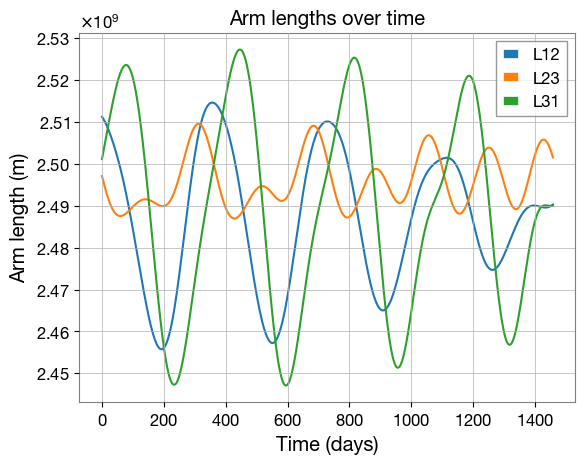

In [27]:
t = np.arange(0, orb_size*orb_dt, orb_dt)
plt.plot(t/86400, L12)
plt.plot(t/86400, L23)
plt.plot(t/86400, L31)
plt.xlabel('Time (days)')
plt.ylabel('Arm length (m)')
plt.title('Arm lengths over time')
plt.legend(['L12', 'L23', 'L31'])
plt.show()

In [28]:
orb.close()

In [22]:
orb_size*orb_dt/(86400)*0.01

np.float64(14.594907407407407)

In [7]:
from pycbc.waveform import get_fd_waveform

m1, m2 = 1e4, 1e4
c = 3e8
G = 6.67e-11
M = (m1 + m2)*2e30
r = 6
f_lower = (c**3)/(((6*r)**1.5)*np.pi*G*M)

hp_fd, hc_fd = get_fd_waveform(approximant="IMRPhenomXHM",
                                       mass1=m1, mass2=m2, delta_f=f_lower/1e3,
                                       f_lower=f_lower, distance=1e4, 
                                           spin1z = 0, spin2z = 0)
hp = hp_fd.to_timeseries()
hc = hc_fd.to_timeseries()

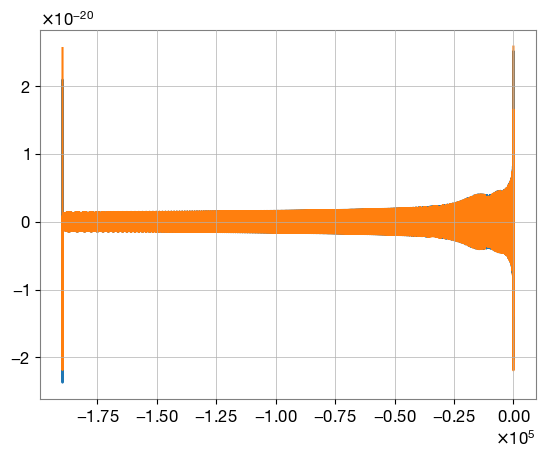

In [6]:
hp.plot()
hc.plot()